# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [2]:
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

Draw a dispersion diagram (scatter plot) for the data.

<Axes: xlabel='Age', ylabel='Tardies'>

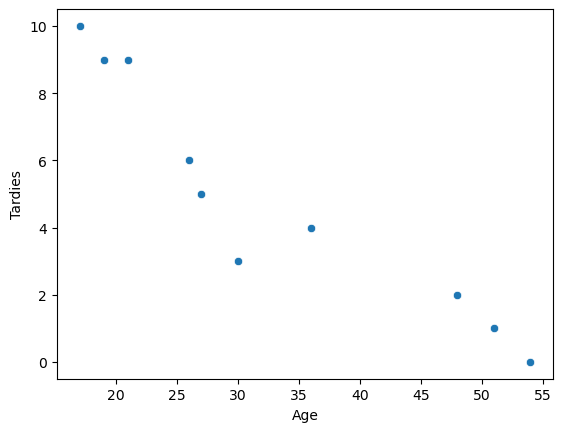

In [7]:
sns.scatterplot(student_data, x="Age", y="Tardies")

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

Yes, there seems to be a clear linear (negative) relationship between age and tardiness that can be hypothesized.

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [ ]:
student_data.cov()
# There is negative covariance between Tardies and Age - as expected. 
# However, the Covariance cannot immediately be interpreted as it needs to seen in proportion with the unit and variance of each variable.

,Age,Tardies
Age,187.655556,-45.566667
Tardies,-45.566667,12.544444


In [ ]:
student_data.corr()
# Here, we see the clear and strong negative correlation between Age and Tardies that is also visible in the scatter plot.

,Age,Tardies
Age,1.000000,-0.939163
Tardies,-0.939163,1.000000


Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [30]:
# In principle, both variables could be used as the outcome variable, but it seems to make more sense in 
# practice to predict tardiness based on age instead of the other way around. 
# We will use linear regression to predict tardiness from age.
reg = LinearRegression().fit(student_data[["Age"]], student_data["Tardies"])
print(reg.score(student_data[["Age"]], student_data["Tardies"]))
print(reg.coef_)
print(reg.intercept_)
print(reg.predict([[40]]))

0.8820265558250109
[-0.24282077]
12.888803363135771
[3.17597253]


c:\Users\gkahl\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Plot your regression model on your scatter plot.

In [28]:
y = []
for i in student_data["Age"]:
    y.append(reg.intercept_ + i*reg.coef_)

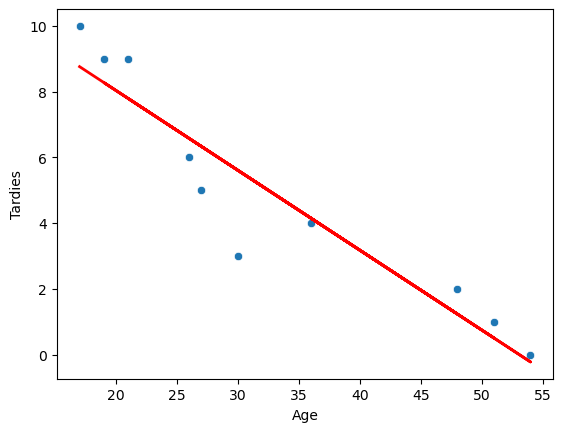

In [ ]:
sns.scatterplot(student_data, x="Age", y="Tardies")
plt.plot(student_data["Age"], y, 'r-', lw=2, label='Linear Regression')
plt.show()



Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

Judging from the available data, age seems to be a good predictor of tardiness. The R²-Score is at 0.88, which is very good. There is also no risk of overfitting as the model is linear.

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [33]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [ ]:
vars = ["Year", "Cylinders", "Fuel Barrels/Year", "Combined MPG", "Fuel Cost/Year"] #, "CO2 Emission Grams/Mile"
y = vehicles["CO2 Emission Grams/Mile"]
vehic = pd.concat([vehicles[vars], y], axis=1)
vehic.corr()[5:6]
# The most important variables seem to be Fuel Barrels/Year, Combined MPG, Fuel Cost/Year and Cylinders.
# Year provides the least impact on the outcome variable.

,Year,Cylinders,Fuel Barrels/Year,Combined MPG,Fuel Cost/Year,CO2 Emission Grams/Mile
CO2 Emission Grams/Mile,-0.2223,0.752393,0.986189,-0.926229,0.930865,1.0


Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [58]:
# Let us use multiple linear regression and compare with and without "year".
reg_co2 = LinearRegression().fit(vehicles[vars], y)
print(reg_co2.score(vehicles[vars], y))
print(reg_co2.coef_)
print(reg_co2.intercept_)
#print(reg_co2.predict([[40]]))

0.9808734920269122
[-0.32061673  1.87879976 19.05292507 -3.04039938  0.03230948]
769.8882836465659


In [ ]:
vars2 = ["Cylinders", "Fuel Barrels/Year", "Combined MPG", "Fuel Cost/Year"]
reg_co22 = LinearRegression().fit(vehicles[vars2], y)
print(reg_co22.score(vehicles[vars2], y))
print(reg_co22.coef_)
print(reg_co22.intercept_)
# Including the variable "year" improves the fit a little bit, bit not much. One can argue if the variable could be excluded.

0.9802919387898396
[ 1.04483633 19.62713308 -3.16658852  0.029393  ]
131.15632475418562


Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

The Goodness of fit is very high and there is no risk of overfitting as the model is linear. This means the model seems to capture the data well. The coefficients 
[-0.32061673  1.87879976 19.05292507 -3.04039938  0.03230948]
indicate how much CO2 changes for each unit change in the respective variable.

In [ ]:
reg_co2

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [84]:
df = pd.DataFrame({"X": [1, 3, 4, 6, 8, 9, 11, 14], "Y": [1, 2, 4, 4, 5, 7, 8, 13]})
df.head()

,X,Y
0,1,1
1,3,2
2,4,4
3,6,4
4,8,5


In [85]:
df.corr()

,X,Y
X,1.00000,0.96523
Y,0.96523,1.00000


Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

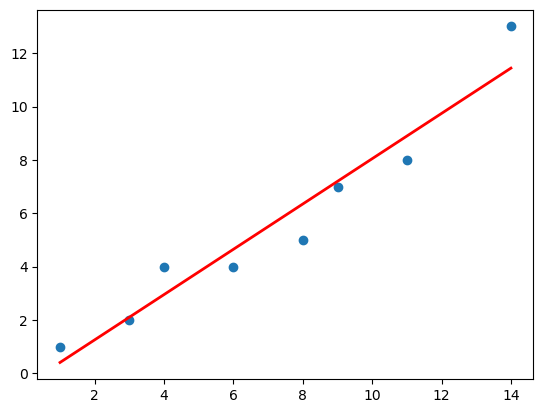

In [73]:
plt.scatter(x=df["X"], y=df["Y"])
reg_attend = LinearRegression().fit(df[["X"]], df["Y"])
attend = reg_attend.predict(df[["X"]])
plt.plot(df["X"], attend, 'r-', lw=2, label='Linear Regression')


What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

In [76]:
print(reg_attend.score(df[["X"]], df["Y"]))
print(reg_attend.coef_)
print(reg_attend.intercept_)

0.9316696375519905
[0.84848485]
-0.43939393939393945


The variables seem to be closely correlated with a high goodness of fit in the linear regression (0.93).

0.9691642263816204


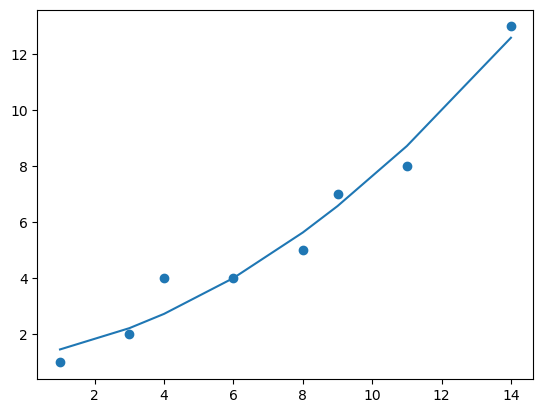

In [ ]:
# Let's try a quadratic model:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[["X"]])

reg_poly = LinearRegression().fit(X_poly, df["Y"])
y_poly = reg_poly.predict(X_poly)
plt.plot(df["X"], y_poly)
plt.scatter(x=df["X"], y=df["Y"])
print(reg_poly.score(X_poly, df["Y"]))

plt.show()
# The goodness of fit is now even better with 0.97. There is a danger of overfitting now. This model corresponds 
# to the claim that "the more people I invite, the higher proportion of them tends to attend."

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

0.9433811802232855
[0.68421053]
0.32330827067669254


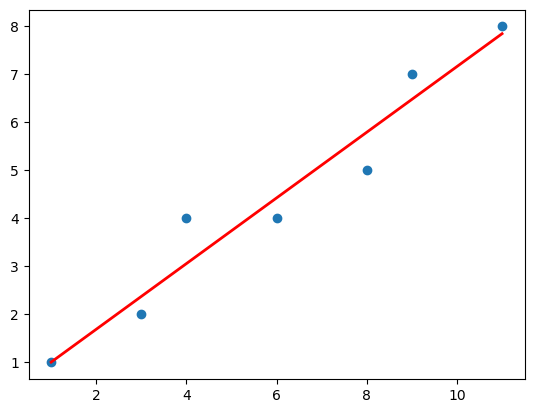

In [ ]:
# Let us exclude the last data point and try linear regression:
df = pd.DataFrame({"X": [1, 3, 4, 6, 8, 9, 11], "Y": [1, 2, 4, 4, 5, 7, 8]})
plt.scatter(x=df["X"], y=df["Y"])
reg_attend = LinearRegression().fit(df[["X"]], df["Y"])
attend = reg_attend.predict(df[["X"]])
plt.plot(df["X"], attend, 'r-', lw=2, label='Linear Regression')
print(reg_attend.score(df[["X"]], df["Y"]))
print(reg_attend.coef_)
print(reg_attend.intercept_)

The goodness of fit is now higher and the slope is less close to 1. If we have high confidence that the last point was an outlier, we may argue that there is a trend of only 68% of our friends to follow our invitation.

0.9885900315488714


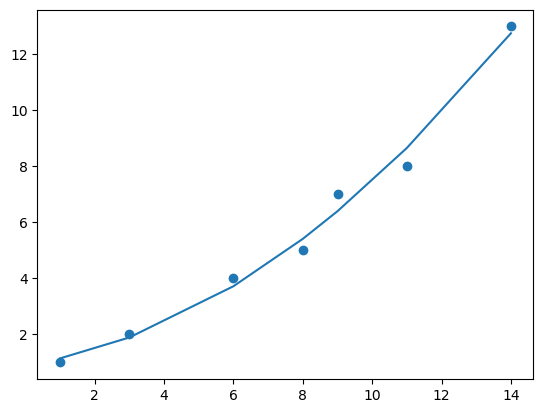

In [83]:
# Let us exclude (4,4) and try quadratic regression again:
df = pd.DataFrame({"X": [1, 3, 6, 8, 9, 11, 14], "Y": [1, 2, 4, 5, 7, 8, 13]})
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[["X"]])

reg_poly = LinearRegression().fit(X_poly, df["Y"])
y_poly = reg_poly.predict(X_poly)
plt.plot(df["X"], y_poly)
plt.scatter(x=df["X"], y=df["Y"])
print(reg_poly.score(X_poly, df["Y"]))

plt.show()

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

Without (4,4), the goodness of fit for quadratic regression is at 0.98, which is very strong. But if we exclude the last data point (14,13), linear regression looks better.